In [14]:
# =========================================================
# REGIONAL FORECASTING + WALK-FORWARD VALIDATION
# BEST MODEL: ROLLING MEAN BASELINE (2)
# =========================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from google.colab import drive

In [15]:
# =========================================================
# 1. DEFINE PROJECT PATHS
# =========================================================

drive.mount('/content/drive')
project_path = "/content/drive/MyDrive/DataAnalytics/UKHousingAffordabilityAnalysis"

processed_data_path = os.path.join(project_path, "Data", "Processed")
figures_path = os.path.join(project_path, "Outputs", "Figures")
tables_path = os.path.join(project_path, "Outputs", "Tables")
metrics_path = os.path.join(project_path, "Outputs", "Metrics")

os.makedirs(figures_path, exist_ok=True)
os.makedirs(tables_path, exist_ok=True)
os.makedirs(metrics_path, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# =========================================================
# 2. LOAD PROCESSED DATASET
# =========================================================

file_path = os.path.join(
    processed_data_path,
    "UKHousingAffordabilityDataset.csv"
)

df = pd.read_csv(file_path)

In [17]:
# =========================================================
# 3. FINAL CLEANING
# =========================================================

numeric_cols = [
    "Year",
    "Affordability_Ratio_Earnings"
]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df = df.dropna(subset=["Year", "Region name", "Affordability_Ratio_Earnings"]).copy()

In [18]:
# =========================================================
# 4. BUILD REGIONAL ANNUAL TIME SERIES
# =========================================================

regional_ts = (
    df.groupby(["Region name", "Year"])["Affordability_Ratio_Earnings"]
    .mean()
    .reset_index()
    .sort_values(["Region name", "Year"])
    .reset_index(drop=True)
)

print("Regional time series preview:")
print(regional_ts.head())

Regional time series preview:
     Region name  Year  Affordability_Ratio_Earnings
0  East Midlands  2002                      4.114545
1  East Midlands  2003                      5.047714
2  East Midlands  2004                      5.922571
3  East Midlands  2005                      6.127143
4  East Midlands  2006                      6.259429


In [19]:
# =========================================================
# 5. HELPER FUNCTIONS
# =========================================================

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

def rolling_mean_forecast(history, window=3):
    return np.mean(history[-window:])


In [20]:
# =========================================================
# 6. SETTINGS
# =========================================================

rolling_window = 2
test_years = 5
forecast_horizon = 5

regional_holdout_results = []
regional_validation_results = []
regional_forecasts = []
regional_test_predictions = []
regional_validation_predictions = []

In [21]:
# =========================================================
# 7. LOOP THROUGH EACH REGION
# =========================================================

for region, region_df in regional_ts.groupby("Region name"):

    region_df = region_df.sort_values("Year").reset_index(drop=True)

    # Need enough observations for rolling window + test set
    if len(region_df) < (rolling_window + test_years):
        print(f"Skipping {region}: not enough observations")
        continue

    # -----------------------------------------------------
    # A. HOLDOUT TRAIN/TEST FORECASTING PER REGION
    # -----------------------------------------------------

    train_df = region_df.iloc[:-test_years].copy()
    test_df = region_df.iloc[-test_years:].copy()

    history = train_df["Affordability_Ratio_Earnings"].tolist()
    test_preds = []

    for actual in test_df["Affordability_Ratio_Earnings"]:
        pred = rolling_mean_forecast(history, window=rolling_window)
        test_preds.append(pred)
        history.append(actual)

    test_preds = np.array(test_preds)

    regional_holdout_results.append({
        "Region name": region,
        "Train_Start_Year": int(train_df["Year"].min()),
        "Train_End_Year": int(train_df["Year"].max()),
        "Test_Start_Year": int(test_df["Year"].min()),
        "Test_End_Year": int(test_df["Year"].max()),
        "MAE": mean_absolute_error(test_df["Affordability_Ratio_Earnings"], test_preds),
        "RMSE": rmse(test_df["Affordability_Ratio_Earnings"], test_preds)
    })

    temp_test = test_df.copy()
    temp_test["Predicted_Affordability_Ratio"] = test_preds
    temp_test["Prediction_Type"] = "Holdout Test"
    temp_test["Model"] = "Rolling Mean Baseline (2)"
    regional_test_predictions.append(temp_test)

    # -----------------------------------------------------
    # B. 5-YEAR FUTURE FORECAST PER REGION
    # -----------------------------------------------------

    full_history = region_df["Affordability_Ratio_Earnings"].tolist()
    future_preds = []

    for _ in range(forecast_horizon):
        pred = rolling_mean_forecast(full_history, window=rolling_window)
        future_preds.append(pred)
        full_history.append(pred)

    future_years = list(
        range(
            int(region_df["Year"].max()) + 1,
            int(region_df["Year"].max()) + forecast_horizon + 1
        )
    )

    forecast_region_df = pd.DataFrame({
        "Region name": region,
        "Year": future_years,
        "Forecast_Affordability_Ratio": future_preds,
        "Model": "Rolling Mean Baseline (2)"
    })

    regional_forecasts.append(forecast_region_df)

    # -----------------------------------------------------
    # C. WALK-FORWARD VALIDATION PER REGION
    # -----------------------------------------------------

    actual_vals = []
    pred_vals = []
    validation_years = []

    for i in range(rolling_window, len(region_df)):
        history = region_df["Affordability_Ratio_Earnings"].iloc[:i].tolist()
        pred = rolling_mean_forecast(history, window=rolling_window)
        actual = region_df["Affordability_Ratio_Earnings"].iloc[i]
        year = region_df["Year"].iloc[i]

        pred_vals.append(pred)
        actual_vals.append(actual)
        validation_years.append(year)

    regional_validation_results.append({
        "Region name": region,
        "Validation_Observations": len(actual_vals),
        "Validation_Start_Year": int(validation_years[0]),
        "Validation_End_Year": int(validation_years[-1]),
        "MAE": mean_absolute_error(actual_vals, pred_vals),
        "RMSE": rmse(actual_vals, pred_vals)
    })

    validation_pred_df = pd.DataFrame({
        "Region name": region,
        "Year": validation_years,
        "Actual_Affordability_Ratio": actual_vals,
        "Predicted_Affordability_Ratio": pred_vals,
        "Prediction_Type": "Walk-Forward Validation",
        "Model": "Rolling Mean Baseline (2)"
    })

    regional_validation_predictions.append(validation_pred_df)

In [22]:
# =========================================================
# 8. COMBINE OUTPUTS
# =========================================================

regional_holdout_results_df = pd.DataFrame(regional_holdout_results).sort_values("RMSE")
regional_validation_results_df = pd.DataFrame(regional_validation_results).sort_values("RMSE")
regional_forecasts_df = pd.concat(regional_forecasts, ignore_index=True)
regional_test_predictions_df = pd.concat(regional_test_predictions, ignore_index=True)
regional_validation_predictions_df = pd.concat(regional_validation_predictions, ignore_index=True)

print("\nHoldout test performance by region:")
print(regional_holdout_results_df)

print("\nWalk-forward validation performance by region:")
print(regional_validation_results_df)

print("\nRegional forecast preview:")
print(regional_forecasts_df.head())


Holdout test performance by region:
                Region name  Train_Start_Year  Train_End_Year  \
3                North East              2002            2019   
9  Yorkshire and The Humber              2002            2019   
7                     Wales              2002            2019   
8             West Midlands              2002            2019   
4                North West              2002            2019   
0             East Midlands              2002            2019   
6                South West              2002            2019   
5                South East              2002            2019   
1           East of England              2002            2019   
2                    London              2002            2019   

   Test_Start_Year  Test_End_Year       MAE      RMSE  
3             2020           2024  0.276833  0.315820  
9             2020           2024  0.296733  0.389024  
7             2020           2024  0.363091  0.428146  
8             2020     

In [23]:
# =========================================================
# 10. SUMMARY TABLES
# =========================================================

holdout_summary = pd.DataFrame({
    "Metric": [
        "Number of Regions",
        "Average Holdout MAE",
        "Average Holdout RMSE",
        "Best Holdout RMSE Region",
        "Worst Holdout RMSE Region"
    ],
    "Value": [
        regional_holdout_results_df["Region name"].nunique(),
        round(regional_holdout_results_df["MAE"].mean(), 4),
        round(regional_holdout_results_df["RMSE"].mean(), 4),
        regional_holdout_results_df.loc[regional_holdout_results_df["RMSE"].idxmin(), "Region name"],
        regional_holdout_results_df.loc[regional_holdout_results_df["RMSE"].idxmax(), "Region name"]
    ]
})

validation_summary = pd.DataFrame({
    "Metric": [
        "Number of Regions",
        "Average Validation MAE",
        "Average Validation RMSE",
        "Best Validation RMSE Region",
        "Worst Validation RMSE Region"
    ],
    "Value": [
        regional_validation_results_df["Region name"].nunique(),
        round(regional_validation_results_df["MAE"].mean(), 4),
        round(regional_validation_results_df["RMSE"].mean(), 4),
        regional_validation_results_df.loc[regional_validation_results_df["RMSE"].idxmin(), "Region name"],
        regional_validation_results_df.loc[regional_validation_results_df["RMSE"].idxmax(), "Region name"]
    ]
})

print("\nHoldout summary:")
print(holdout_summary)


Holdout summary:
                      Metric       Value
0          Number of Regions          10
1        Average Holdout MAE      0.4751
2       Average Holdout RMSE      0.5695
3   Best Holdout RMSE Region  North East
4  Worst Holdout RMSE Region      London


In [24]:
# =========================================================
# 9. SAVE OUTPUTS
# =========================================================

regional_holdout_results_df.to_csv(
    os.path.join(metrics_path, "Regional_RollingMean_Holdout_Performance.csv"),
    index=False
)

regional_validation_results_df.to_csv(
    os.path.join(metrics_path, "Regional_RollingMean_WalkForward_Validation.csv"),
    index=False
)

regional_forecasts_df.to_csv(
    os.path.join(tables_path, "Regional_RollingMean_5Year_Forecast.csv"),
    index=False
)

regional_test_predictions_df.to_csv(
    os.path.join(tables_path, "Regional_RollingMean_Test_Predictions.csv"),
    index=False
)

regional_validation_predictions_df.to_csv(
    os.path.join(tables_path, "Regional_RollingMean_Validation_Predictions.csv"),
    index=False
)



print("\nWalk-forward validation summary:")
print(validation_summary)

holdout_summary.to_csv(
    os.path.join(metrics_path, "Regional_RollingMean_Holdout_Summary.csv"),
    index=False
)

validation_summary.to_csv(
    os.path.join(metrics_path, "Regional_RollingMean_Validation_Summary.csv"),
    index=False
)





Walk-forward validation summary:
                         Metric       Value
0             Number of Regions          10
1        Average Validation MAE      0.4174
2       Average Validation RMSE      0.5437
3   Best Validation RMSE Region  North East
4  Worst Validation RMSE Region      London


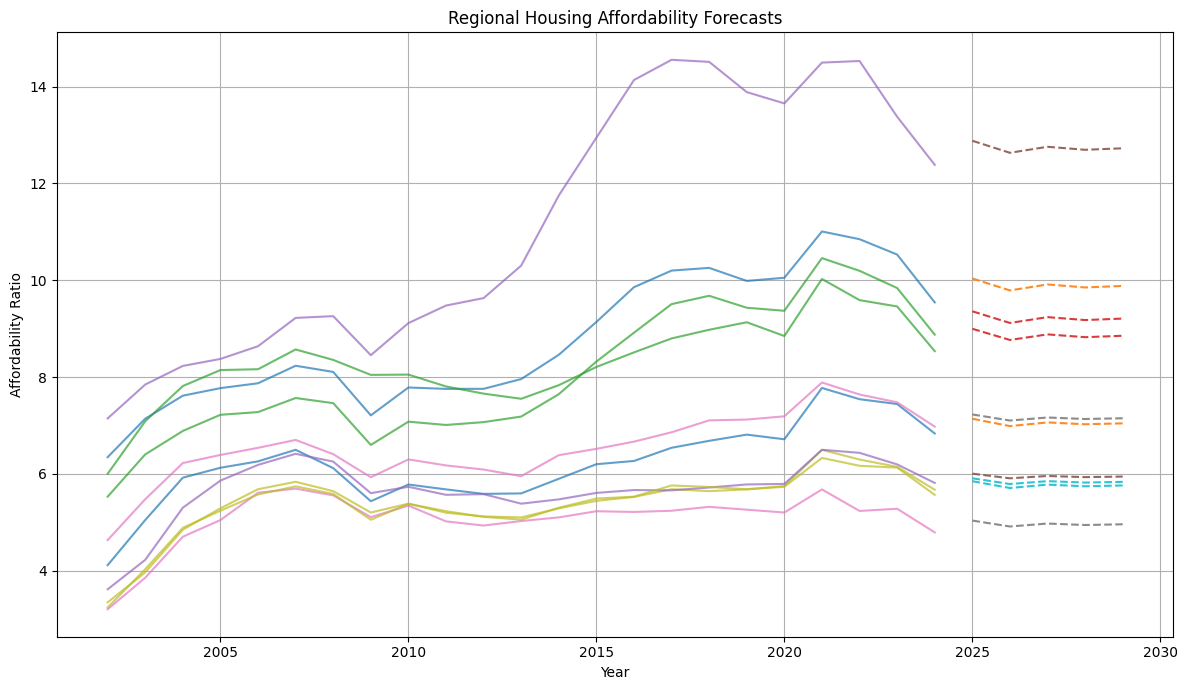

In [25]:

# =========================================================
# 11. PLOT ALL REGIONAL FORECASTS
# =========================================================

plt.figure(figsize=(12, 7))

for region in regional_forecasts_df["Region name"].unique():
    hist_region = regional_ts[regional_ts["Region name"] == region]
    fc_region = regional_forecasts_df[regional_forecasts_df["Region name"] == region]

    plt.plot(
        hist_region["Year"],
        hist_region["Affordability_Ratio_Earnings"],
        alpha=0.7
    )

    plt.plot(
        fc_region["Year"],
        fc_region["Forecast_Affordability_Ratio"],
        linestyle="--",
        alpha=0.9
    )

plt.title("Regional Housing Affordability Forecasts")
plt.xlabel("Year")
plt.ylabel("Affordability Ratio")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "Regional_RollingMean_5Year_Forecasts.png"))
plt.show()


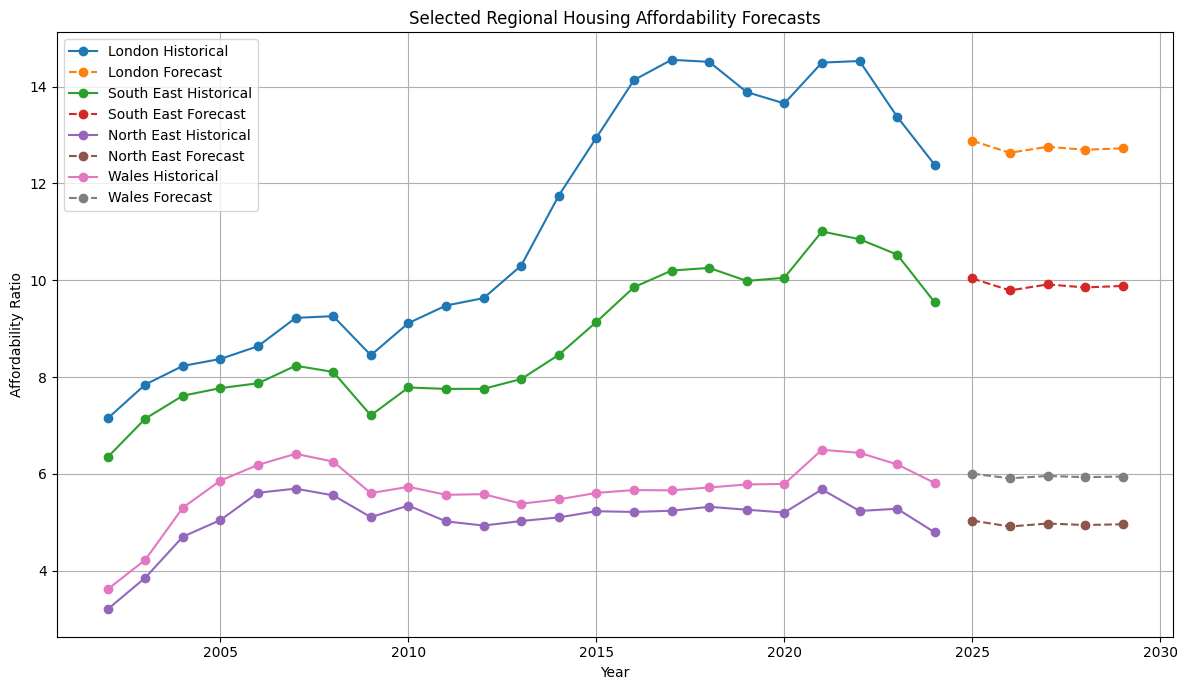

In [26]:
# =========================================================
# 12. PLOT SELECTED REGIONS
# =========================================================

selected_regions = [
    "London",
    "South East",
    "North East",
    "Wales"
]

plt.figure(figsize=(12, 7))

for region in selected_regions:
    if region not in regional_ts["Region name"].unique():
        continue

    hist_region = regional_ts[regional_ts["Region name"] == region]
    fc_region = regional_forecasts_df[regional_forecasts_df["Region name"] == region]

    plt.plot(
        hist_region["Year"],
        hist_region["Affordability_Ratio_Earnings"],
        marker="o",
        label=f"{region} Historical"
    )

    plt.plot(
        fc_region["Year"],
        fc_region["Forecast_Affordability_Ratio"],
        marker="o",
        linestyle="--",
        label=f"{region} Forecast"
    )

plt.title("Selected Regional Housing Affordability Forecasts")
plt.xlabel("Year")
plt.ylabel("Affordability Ratio")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "Selected_Regional_RollingMean_Forecasts.png"))
plt.show()